<a href="https://colab.research.google.com/github/alessiobsc/AI4Cyber-FaceRecognitionSecurity/blob/main/AI4Cyber_ProjectWork_Base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount= True)

Mounted at /content/drive


In [ ]:
!pip install adversarial-robustness-toolbox # ART libreria per generare e valutare attacchi adversarial
!pip install torch torchvision
!pip install facenet_pytorch

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image

# Import da ART
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import ProjectedGradientDescent
from art.defences.preprocessor import SpatialSmoothing

# Verifica che la GPU sia disponibile
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo in uso: {device}")

Dispositivo in uso: cuda


# Fase 1

In [ ]:
import pandas as pd
import subprocess
import os

# ==========================================
# 1. CONFIGURAZIONE PERCORSI
# ==========================================
CSV_PATH = '/content/drive/MyDrive/Colab Notebooks/AI4Cyber/PW/identity_meta.csv'
ARCHIVIO_DRIVE = '/content/drive/MyDrive/Colab Notebooks/AI4Cyber/PW/vggface2_train.tar.gz'
ARCHIVIO_LOCALE = '/content/vgg_temp.tar.gz'
OUTPUT_LOCAL_DIR = '/content/dataset_progetto'
DESTINAZIONE_DRIVE = '/content/drive/MyDrive/Colab Notebooks/AI4Cyber/PW/Dataset_Selezionato_Progetto'

ID_CERCI = '250' # Verrà gestito come stringa per matchare il dataset

# ==========================================
# 2. SELEZIONE LOGICA (FLAG = 1)
# ==========================================
print("--- FASE 1: Selezione Identità (Metodo Clean) ---")
df = pd.read_csv(CSV_PATH, on_bad_lines='skip')

# Pulizia: rimuoviamo spazi e assicuriamoci che Class_ID sia stringa
df.columns = df.columns.str.strip()
df['Class_ID'] = df['Class_ID'].astype(str).str.strip()
df['Gender'] = df['Gender'].str.strip()

# Se Cerci non viene trovato, cerchiamo con il prefisso 'n' tipico del dataset.
if ID_CERCI not in df['Class_ID'].values:
    ID_CERCI = 'n' + ID_CERCI.zfill(6)

# FILTRO LOGICO: Solo soggetti presenti nel Training Set (Flag == 1)
df_train = df[df['Flag'] == 1].copy()

# Stratified Sampling (50 Maschi, 50 Femmine)
df_m = df_train[df_train['Gender'] == 'm']
df_f = df_train[df_train['Gender'] == 'f']

# Assicuriamoci che Cerci sia nel pool maschile
if ID_CERCI not in df_m['Class_ID'].values:
    print(f"ATTENZIONE: L'ID {ID_CERCI} non è stato trovato nel Train Set con Gender='m'.")
    males_sampled = df_m.sample(n=50, random_state=42)['Class_ID'].tolist()
else:
    males_sampled = df_m[df_m['Class_ID'] != ID_CERCI].sample(n=49, random_state=42)['Class_ID'].tolist()
    males_sampled.append(ID_CERCI)

females_sampled = df_f.sample(n=50, random_state=42)['Class_ID'].tolist()

identita_selezionate = males_sampled + females_sampled
cartelle_da_estrarre = [f"train/{id_val}" for id_val in identita_selezionate]

print(f"Selezionate {len(identita_selezionate)} identità dal Training Set.")

# ==========================================
# 3. ESTRAZIONE VELOCE (LOCAL SSD)
# ==========================================
print("\n--- FASE 2: Estrazione Veloce ---")
os.makedirs(OUTPUT_LOCAL_DIR, exist_ok=True)

print("1. Copia dell'archivio da Drive a Colab...")
!cp "{ARCHIVIO_DRIVE}" "{ARCHIVIO_LOCALE}"

print("2. Estrazione selettiva dal disco locale...")
comando_tar = ['tar', '-xzf', ARCHIVIO_LOCALE, '-C', OUTPUT_LOCAL_DIR] + cartelle_da_estrarre
subprocess.run(comando_tar)

print("3. Pulizia file temporaneo...")
if os.path.exists(ARCHIVIO_LOCALE): os.remove(ARCHIVIO_LOCALE)

# ==========================================
# 4. SALVATAGGIO PERMANENTE
# ==========================================
print("\n--- FASE 3: Sincronizzazione con Drive ---")
!cp -r {OUTPUT_LOCAL_DIR} "{DESTINAZIONE_DRIVE}"

# Verifica finale
percorso_output = os.path.join(OUTPUT_LOCAL_DIR, 'train')
if os.path.exists(percorso_output):
    final_count = len(os.listdir(percorso_output))
    print(f"Missione compiuta! Identità totali nel dataset finale: {final_count}")
else:
    print("Errore: la cartella di output è vuota.")

In [ ]:
#Riduce il dataset selezionato mantenendo esattamente 10 immagini per identità
import os
import glob
import random
import shutil

# ==========================================
# 1. POTATURA LOCALE
# ==========================================
DATASET_DIR = '/content/dataset_progetto/train'
DESTINAZIONE_DRIVE = '/content/drive/MyDrive/Colab Notebooks/AI4Cyber/PW/Dataset_Selezionato_Progetto'
IMM_PER_IDENTITA = 10

random.seed(42) # Per riproducibilità

print(f"1. Controllo cartella locale: {DATASET_DIR}")
if os.path.exists(DATASET_DIR):
    cartelle = [f.path for f in os.scandir(DATASET_DIR) if f.is_dir()]
    print(f"Trovate {len(cartelle)} identità. Inizio potatura a {IMM_PER_IDENTITA} immagini ciascuna...")

    immagini_rimosse = 0
    for cartella in cartelle:
        immagini = glob.glob(os.path.join(cartella, '*.*'))
        if len(immagini) > IMM_PER_IDENTITA:
            da_mantenere = set(random.sample(immagini, IMM_PER_IDENTITA))
            for img_path in immagini:
                if img_path not in da_mantenere:
                    os.remove(img_path)
                    immagini_rimosse += 1

    print(f"Potatura completata! Rimosse {immagini_rimosse} immagini in eccesso.")

    # ==========================================
    # 2. SALVATAGGIO SU DRIVE
    # ==========================================
    print("\n2. Inizio sincronizzazione del mini-dataset su Drive...")

    if os.path.exists(DESTINAZIONE_DRIVE):
        print("Rilevata cartella precedente su Drive, pulizia in corso per sicurezza...")
        shutil.rmtree(DESTINAZIONE_DRIVE)

    # Copia veloce dei 1000 file rimanenti
    os.system(f'cp -r /content/dataset_progetto "{DESTINAZIONE_DRIVE}"')

    # Verifica finale su Drive
    if os.path.exists(os.path.join(DESTINAZIONE_DRIVE, 'train')):
        conteggio = sum([len(files) for r, d, files in os.walk(os.path.join(DESTINAZIONE_DRIVE, 'train'))])
        print(f"\Il dataset definitivo ha esattamente {conteggio} immagini salvate su Drive.")
    else:
        print("\nErrore durante la copia finale su Drive.")
else:
    print("\nERRORE CRITICO: La cartella locale non esiste.")

In [ ]:
#100 idendità e che ogni cartella contenga esattamente 10 immagini, per un totale di 100 immagini
import os

path_drive = '/content/drive/MyDrive/Colab Notebooks/AI4Cyber/PW/Dataset_Selezionato_Progetto/train'

if os.path.exists(path_drive):
    cartelle = [d for d in os.listdir(path_drive) if os.path.isdir(os.path.join(path_drive, d))]

    report_errori = []
    totale_immagini = 0

    for c in cartelle:
        p_completo = os.path.join(path_drive, c)
        n_foto = len([f for f in os.listdir(p_completo) if os.path.isfile(os.path.join(p_completo, f))])
        totale_immagini += n_foto

        if n_foto != 10:
            report_errori.append(f"ID {c}: {n_foto} immagini")

    print(f"--- VERIFICA INTEGRITÀ ---")
    print(f"Identità totali: {len(cartelle)}")
    print(f"Immagini totali: {totale_immagini}")

    if len(report_errori) == 0 and totale_immagini == 1000:
        print("\nPERFETTO: Tutte le 100 identità hanno esattamente 10 immagini.")
    else:
        print("\nANOMALIA RILEVATA nelle seguenti cartelle:")
        for err in report_errori:
            print(err)
else:
    print("Errore: Il percorso su Drive non è raggiungibile.")

In [ ]:
import pandas as pd

# 1. Recuperiamo automaticamente gli ID dalle cartelle che hai appena verificato
path_drive = '/content/drive/MyDrive/Colab Notebooks/AI4Cyber/PW/Dataset_Selezionato_Progetto/train'

if os.path.exists(path_drive):
    # La lista delle cartelle corrisponde alla lista degli ID (es. 'n000001')
    selected_ids = [d for d in os.listdir(path_drive) if os.path.isdir(os.path.join(path_drive, d))]
    print(f"Estratti con successo {len(selected_ids)} ID dalle directory.")
else:
    print("Errore: impossibile accedere alle cartelle su Drive.")
    selected_ids = []

# 2. Imposta il percorso del file CSV contenente i metadati di VGG-Face2
csv_meta_path = '/content/drive/MyDrive/Colab Notebooks/AI4Cyber/PW/identity_meta.csv'

try:
    # Carichiamo il dataset
    df_meta = pd.read_csv(csv_meta_path, on_bad_lines='skip')

    # Pulizia preventiva dei nomi delle colonne
    df_meta.columns = df_meta.columns.str.strip()

    # Adattiamo i nomi delle colonne allo standard VGG-Face2
    col_id = 'Class_ID'
    col_name = 'Name'

    # Puliamo gli ID nel dataframe rimuovendo eventuali spazi e apici
    df_meta[col_id] = df_meta[col_id].astype(str).str.strip().str.replace('"', '').str.replace("'", "")

    # 3. Filtriamo il dataframe mantenendo solo le righe il cui ID è presente nel nostro dataset di 100 soggetti
    df_filtrato = df_meta[df_meta[col_id].isin(selected_ids)]

    print(f"\n--- MAPPA IDENTITÀ ({len(df_filtrato)} trovate) ---\n")
    print(df_filtrato[[col_id, col_name]].to_string(index=False))

except FileNotFoundError:
    print(f"\n[ERRORE] Il file '{csv_meta_path}' non è stato trovato.")
except KeyError as e:
    print(f"\n[ERRORE] Colonna non trovata: {e}")
    print(f"Colonne disponibili nel CSV: {list(df_meta.columns)}")

# Fase 2


In [ ]:
from facenet_pytorch import InceptionResnetV1
#Carica un modello già allenato sul dataset VGGFace2 e lo mette in fase di inferenza
resnet = InceptionResnetV1(pretrained='vggface2').eval()
#modalità classificazione diretta
resnet.classify = True

In [ ]:
resnet.to(device)

InceptionResnetV1(
  (conv2d_1a): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (conv2d_2a): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (conv2d_2b): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (maxpool_3a): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2d_3b): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (conv2d_4a): 

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
from PIL import Image
from torchvision import transforms
from facenet_pytorch import InceptionResnetV1
import tensorflow as tf

# ==========================================
# 1. SETUP MODELLO E LABELS
# ==========================================
print("Inizializzazione modello InceptionResnetV1 (NN1)...")
resnet = InceptionResnetV1(pretrained='vggface2').eval()
resnet.classify = True

# Caricamento delle etichette (VGGFace2) del classificatore
fpath = tf.keras.utils.get_file('rcmalli_vggface_labels_v2.npy',
                             "https://github.com/rcmalli/keras-vggface/releases/download/v2.0/rcmalli_vggface_labels_v2.npy",
                             cache_subdir="./")
LABELS = np.load(fpath)

# ==========================================
# 2. INTEGRAZIONE METADATI (identity_meta.csv)
# ==========================================
# Sostituisci con il path reale del tuo file csv
csv_path = '/content/drive/MyDrive/Colab Notebooks/AI4Cyber/PW/identity_meta.csv'

try:
    # 1. skipinitialspace=True: rimuove gli spazi bianchi insidiosi dopo le virgole
    # 2. on_bad_lines='skip': se una riga ha più colonne del previsto (es. riga 652), la salta
    #    e continua a leggere il resto del file senza andare in crash.
    meta_df = pd.read_csv(csv_path, skipinitialspace=True, on_bad_lines='skip')

    # Pulizia colonne e dati
    meta_df.columns = meta_df.columns.str.strip()
    meta_df['Class_ID'] = meta_df['Class_ID'].astype(str).str.strip().str.replace('"', '').str.replace("'", "")

    # Dizionario: ID -> Nome
    id_to_name = dict(zip(meta_df['Class_ID'], meta_df['Name']))
    print(f"Metadati caricati con successo.")

except Exception as e:
    print(f"Errore caricamento CSV metadati: {e}")
    id_to_name = {}

# ==========================================
# 3. PREPROCESSING MATEMATICO
# ==========================================
preprocess = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    # Normalizzazione lineare da [0, 1] a [-1, 1] per allinearsi all'addestramento originale
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ==========================================
# 4. LOOP DI VALUTAZIONE (CORRETTO)
# ==========================================
# Sostituisci con il path della tua cartella train se diverso
path_drive = '/content/drive/MyDrive/Colab Notebooks/AI4Cyber/PW/Dataset_Selezionato_Progetto/train'

correct_predictions = 0
total_images = 0
error_log = []

print("\nInizio classificazione baseline sul Test Set...")

with torch.no_grad():
    for folder_name in os.listdir(path_drive):
        folder_path = os.path.join(path_drive, folder_name)
        if not os.path.isdir(folder_path):
            continue

        # Otteniamo il VERO NOME dalla cartella usando il nostro dizionario
        # Rimuoviamo eventuali spazi e virgolette per sicurezza
        real_name = id_to_name.get(folder_name, "ID_Sconosciuto").strip().replace('"', '').replace("'", "")

        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)

            try:
                # Caricamento e preprocessing immagine
                img = Image.open(img_path).convert('RGB')
                img_tensor = preprocess(img).unsqueeze(0)

                # Forward pass
                logits = resnet(img_tensor)

                # Predizione
                pred_idx = logits.argmax(dim=1).item()
                # Il file rcmalli_vggface_labels_v2.npy restituisce direttamente i nomi (es. ' Fabio_Fognini')
                pred_name = str(LABELS[pred_idx]).strip().replace('"', '').replace("'", "")

                # Check Ground Truth vs Prediction confrontando i NOMI!
                if real_name == pred_name:
                    correct_predictions += 1
                else:
                    if len(error_log) < 15:
                        error_log.append(f"Vero: {real_name} (ID: {folder_name}) --> Predetto: {pred_name}")

                total_images += 1
                if total_images % 100 == 0:
                    print(f"Analizzate {total_images} immagini...")

            except Exception as e:
                print(f"Errore su {img_path}: {e}")

# ==========================================
# 5. METRICHE
# ==========================================
accuracy = correct_predictions / total_images if total_images > 0 else 0

print(f"\n======================================")
print(f"RISULTATI BASELINE EVALUATION")
print(f"======================================")
print(f"Totale Immagini : {total_images}")
print(f"Corrette (TP)   : {correct_predictions}")
print(f"Accuratezza     : {accuracy * 100:.2f}%")
print(f"======================================\n")

if error_log:
    print("Campione degli errori di classificazione:")
    for err in error_log:
        print(" -", err)

Inizializzazione modello InceptionResnetV1 (NN1)...
1346516/1346516 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Metadati caricati con successo.

Inizio classificazione baseline sul Test Set...
Analizzate 100 immagini...
Analizzate 200 immagini...
Analizzate 300 immagini...
Analizzate 400 immagini...
Analizzate 500 immagini...
Analizzate 600 immagini...
Analizzate 700 immagini...
Analizzate 800 immagini...
Analizzate 900 immagini...
Analizzate 1000 immagini...

RISULTATI BASELINE EVALUATION
Totale Immagini : 1000
Corrette (TP)   : 785
Accuratezza     : 78.50%

Campione degli errori di classificazione:
 - Vero: Agneta_Sjödin (ID: n000108) --> Predetto: Demi_Moore
 - Vero: Agneta_Sjödin (ID: n000108) --> Predetto: Alicia_Sacramone
 - Vero: Agneta_Sjödin (ID: n000108) --> Predetto: Lucie_Jones
 - Vero: Amanda_Palmer (ID: n000385) --> Predetto: Birgit_Minichmayr
 - Vero: Amanda_Palmer (ID: n000385) --> Predetto: Lee_Sun-yeol
 - Vero: Amanda_Palmer (ID: n000385) --> Predetto: Stephanie_Rawlings-Blake
 

# Fase 3

In [ ]:
# Incapsula la rete PyTorch in un classificatore ART.
# Questo wrapper permette ad ART di calcolare gradienti, predizioni
# e attacchi adversarial sul modello NN1. Sono specificati loss,
# ottimizzatore, range dei valori di input, shape delle immagini
# e numero totale di classi VGGFace2.

import torch
from art.estimators.classification import PyTorchClassifier
import torch.optim as optim

# Definizione componenti per ART
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.parameters(), lr=0.01)

# Creazione del wrapper con device esplicito
classifier = PyTorchClassifier(
    model=resnet,
    clip_values=(-1.0, 1.0),
    loss=criterion,
    optimizer=optimizer,
    input_shape=(3, 160, 160),
    nb_classes=8631,
    device_type=device.type # Passa 'cuda' o 'cpu' dinamicamente
)

In [ ]:
# Prepara il test set in formato compatibile con ART.
# Ogni immagine viene ridimensionata, convertita in tensore e normalizzata
# nel range [-1, 1]. Le etichette testuali vengono convertite negli indici
# numerici usati dal classificatore VGGFace2.

import numpy as np

# Mapping inverso: Nome Persona -> Indice numerico del modello
name_to_idx = {name.strip().replace("'", ""): i for i, name in enumerate(LABELS)}

x_test_list = []
y_test_list = []

print("Caricamento delle 1000 immagini del test set...")

for folder_name in os.listdir(path_drive):
    folder_path = os.path.join(path_drive, folder_name)
    if not os.path.isdir(folder_path): continue

    real_name = id_to_name.get(folder_name, "").strip().replace("'", "")
    label_idx = name_to_idx.get(real_name, -1)
    if label_idx == -1: continue

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        try:
            # Preprocessing identico alla baseline (78.5%)
            img_pil = Image.open(img_path).convert('RGB').resize((160, 160))
            img_tns = transforms.ToTensor()(img_pil)
            # Normalizzazione [-1, 1] come deciso
            img_tns = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])(img_tns)

            x_test_list.append(img_tns.numpy())
            y_test_list.append(label_idx)
        except:
            continue

x_test_all = np.array(x_test_list)
y_test_all = np.array(y_test_list)

print(f"Completato! Dataset pronto: {x_test_all.shape}")

Caricamento delle 1000 immagini del test set...
Completato! Dataset pronto: (1000, 3, 160, 160)


## Utility Functions

### Save generated adversarial examples

In [ ]:
import os
import numpy as np

ADV_SAVE_DIR = "/content/drive/MyDrive/Gruppo IA4Cyber"
os.makedirs(ADV_SAVE_DIR, exist_ok=True)

def save_npz_attack(attack_family, attack_mode, epsilon, x_adv, preds_adv, y_true,
                    targeted=False, target_idx=None, target_name=None):
    """
    Salva i campioni adversarial in una struttura ordinata:
    Adversarial_Samples/NOME_ATTACCO/MODALITA/eps_X.npz
    """

    attack_dir = os.path.join(ADV_SAVE_DIR, attack_family, attack_mode)
    os.makedirs(attack_dir, exist_ok=True)

    eps_name = str(epsilon).replace(".", "_")
    file_path = os.path.join(attack_dir, f"eps_{eps_name}.npz")

    np.savez_compressed(
        file_path,
        x_adv=x_adv,
        preds_adv=preds_adv,
        y_true=y_true,
        epsilon=epsilon,
        targeted=targeted,
        target_idx=target_idx if target_idx is not None else -1,
        target_name=target_name if target_name is not None else ""
    )

    print(f"Salvato: {file_path}")

### Load generated adversarial examples

In [ ]:
def load_attack_results(folder_path):
    all_results = {}
    files = [f for f in os.listdir(folder_path) if f.endswith('.npz')]

    for f in files:
        name = f.replace('.npz', '')
        data = np.load(os.path.join(folder_path, f))
        all_results[name] = {
            'x_adv': data['x_adv'],
            'y_true': data['y_true'],
            'y_pred': data['y_pred'],
            'conf': data['conf'],
            'eps': data['eps_range'],
            'l2': data['l2_dist']
        }
        print(f"Caricato attacco: {name}")
    return all_results

# Utilizzo:
# results = load_attack_results('/content/drive/MyDrive/NOME_DELLA_TUA_SCORCIATOIA/npz_name')

In [ ]:
import matplotlib.pyplot as plt

def get_distances(x_orig, x_adv):
    # Calcolo distanze medie sul batch
    diff = (x_adv - x_orig).reshape(x_orig.shape[0], -1)
    l1 = np.mean(np.linalg.norm(diff, ord=1, axis=1))
    l2 = np.mean(np.linalg.norm(diff, ord=2, axis=1))
    linf = np.mean(np.linalg.norm(diff, ord=np.inf, axis=1))
    return l1, l2, linf

def show_adv_comparison(x_orig, x_adv, title=""):
    # Denormalizzazione da [-1, 1] a [0, 1] per la visualizzazione
    orig_img = (x_orig[0].transpose(1, 2, 0) + 1) / 2
    adv_img = (x_adv[0].transpose(1, 2, 0) + 1) / 2
    noise = np.abs(adv_img - orig_img)

    plt.figure(figsize=(10, 3))
    plt.subplot(1, 3, 1); plt.imshow(np.clip(orig_img, 0, 1)); plt.title("Originale")
    plt.subplot(1, 3, 2); plt.imshow(np.clip(adv_img, 0, 1)); plt.title(f"Adv ({title})")
    plt.subplot(1, 3, 3); plt.imshow(np.clip(noise * 10, 0, 1)); plt.title("Rumore (x10)")
    plt.show()

## FGSM Untargeted

In [ ]:
# Genera adversarial examples con attacco FGSM untargeted.
# L'obiettivo è causare una classificazione errata, senza imporre
# una specifica identità target. Per diversi valori di epsilon,
# misura l'accuratezza residua del modello e l'intensità media
# della perturbazione tramite norme L2 e Linf.

from art.attacks.evasion import FastGradientMethod
import numpy as np
import pandas as pd

# Parametri
epsilons = [0.0, 0.05, 0.1, 0.15, 0.2] # Fino al 10% del range
untargeted_results = []

print("Inizio generazione attacco FGSM Untargeted...")

for eps in epsilons:
    if eps == 0:
        # Baseline (Immagini Clean)
        preds = np.argmax(classifier.predict(x_test_all, batch_size=64), axis=1)
        acc = np.sum(preds == y_test_all) / len(y_test_all)
        untargeted_results.append({"Epsilon": eps, "Accuratezza": acc, "L2": 0.0, "Linf_Real": 0.0})
    else:
        # Creazione attacco
        attack_un = FastGradientMethod(estimator=classifier, eps=eps, targeted=False)
        x_adv_un = attack_un.generate(x=x_test_all, batch_size=64)

        # Valutazione accuratezza
        preds_un = np.argmax(classifier.predict(x_adv_un, batch_size=64), axis=1)
        save_npz_attack(
            attack_family="FGSM",
            attack_mode="untargeted",
            epsilon=eps,
            x_adv=x_adv_un,
            preds_adv=preds_un,
            y_true=y_test_all,
            targeted=False
        )
        acc_un = np.sum(preds_un == y_test_all) / len(y_test_all)


        # Calcolo distanze per analisi invasività
        diff = (x_adv_un - x_test_all).reshape(len(x_test_all), -1)
        l2_avg = np.mean(np.linalg.norm(diff, ord=2, axis=1))
        linf_avg = np.mean(np.linalg.norm(diff, ord=np.inf, axis=1))

        untargeted_results.append({
            "Epsilon": eps,
            "Accuratezza": acc_un,
            "L2": l2_avg,
            "Linf_Real": linf_avg
        })

df_untargeted = pd.DataFrame(untargeted_results)
display(df_untargeted)

Inizio generazione attacco FGSM Untargeted...
Salvato: /content/drive/MyDrive/Gruppo IA4Cyber/FGSM/untargeted/eps_0_05.npz
Salvato: /content/drive/MyDrive/Gruppo IA4Cyber/FGSM/untargeted/eps_0_1.npz


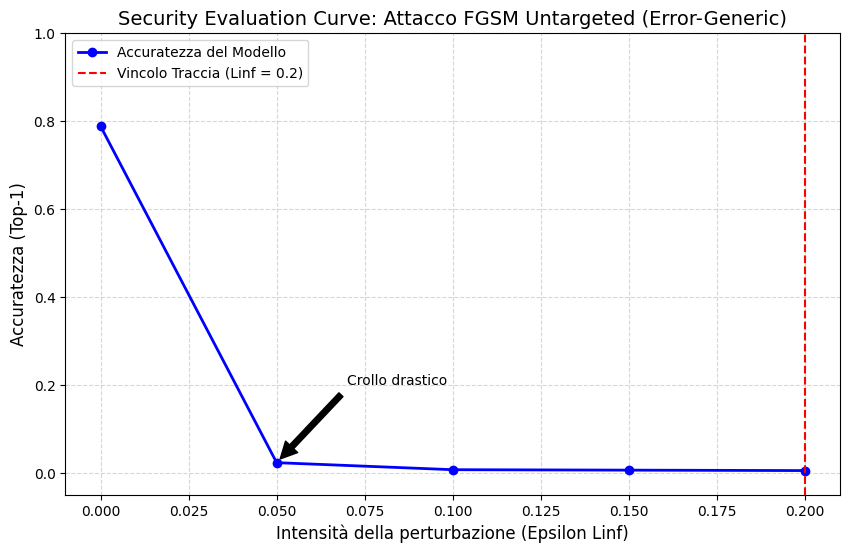


Sintesi Risultati per Relazione (Fase 7):
 Epsilon (Linf) Accuratezza  Distanza L2 Media
           0.00      78.90%               0.00
           0.05       2.40%              13.36
           0.10       0.80%              26.48
           0.15       0.70%              39.37
           0.20       0.60%              52.00


In [ ]:
# Visualizza la Security Evaluation Curve per l'attacco FGSM untargeted.
# Il grafico mostra come l'accuratezza del modello diminuisce
# all'aumentare dell'intensità della perturbazione. La linea verticale
# evidenzia il limite massimo imposto dalla traccia.

import matplotlib.pyplot as plt
import pandas as pd

# Dati estratti dai tuoi risultati per FGSM Untargeted
eps = [0.00, 0.05, 0.10, 0.15, 0.20]
acc = [0.789, 0.024, 0.008, 0.007, 0.006]
l2_dist = [0.00, 13.36, 26.48, 39.37, 52.00] # Basato sui tuoi dati precedenti

# Creazione della figura
plt.figure(figsize=(10, 6))

# Plot della Security Evaluation Curve (Accuratezza)
plt.plot(eps, acc, marker='o', linestyle='-', linewidth=2, color='b', label='Accuratezza del Modello')

# Evidenzia il limite della traccia (10% del range)
plt.axvline(x=0.2, color='r', linestyle='--', label='Vincolo Traccia (Linf = 0.2)')

# Annotazione dell'Epsilon ottimale (punto di rottura)
plt.annotate('Crollo drastico', xy=(0.05, 0.024), xytext=(0.07, 0.2),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title("Security Evaluation Curve: Attacco FGSM Untargeted (Error-Generic)", fontsize=14)
plt.xlabel("Intensità della perturbazione (Epsilon Linf)", fontsize=12)
plt.ylabel("Accuratezza (Top-1)", fontsize=12)
plt.ylim(-0.05, 1.0) # Range dell'accuratezza
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.show()

# Tabella riassuntiva per la discussione (da inserire nella relazione)
df_sec_un = pd.DataFrame({
    'Epsilon (Linf)': eps,
    'Accuratezza': [f"{a*100:.2f}%" for a in acc],
    'Distanza L2 Media': l2_dist
})
print("\nSintesi Risultati per Relazione (Fase 7):")
print(df_sec_un.to_string(index=False))

In [ ]:
# Genera adversarial examples con FGSM targeted verso Alessio Cerci.
# Per ogni valore di epsilon, misura l'Attack Success Rate,
# cioè la percentuale di immagini che il modello classifica come Cerci.
# Calcola inoltre la distanza L2 media per valutare l'invasività
# della perturbazione.

# Cerchiamo Alessio Cerci nell'array LABELS usato dal modello
target_name_ricerca = "Alessio_Cerci"
clean_labels = [str(l).strip().replace("'", "").replace('"', '') for l in LABELS]

try:
    real_target_idx = clean_labels.index(target_name_ricerca)
    print(f"L'indice CORRETTO per il modello è: {real_target_idx}")
    print(f"Nome confermato dal modello: {LABELS[real_target_idx]}")
except ValueError:
    # Se non lo trova, cerchiamo chi c'è vicino o con nome simile
    possibili = [i for i, s in enumerate(clean_labels) if "Cerci" in s]
    print(f"Indici che contengono 'Cerci': {possibili}")
    real_target_idx = possibili[0] if possibili else 250 # Fallback

L'indice CORRETTO per il modello è: 235
Nome confermato dal modello:  Alessio_Cerci


In [ ]:
# Visualizza i risultati dell'attacco targeted.
# Il primo grafico mostra l'Attack Success Rate al variare di epsilon,
# mentre il secondo grafico mostra la distanza L2 media,
# utile per discutere il compromesso tra efficacia e visibilità del rumore.

from art.attacks.evasion import FastGradientMethod
import numpy as np
import pandas as pd

# Parametri per l'attacco mirato
target_idx = real_target_idx
epsilons = [0.0, 0.05, 0.1, 0.15, 0.2]
y_target_all = np.full(y_test_all.shape, target_idx)

targeted_results = []

print(f"Inizio generazione attacco Targeted (Target: {LABELS[target_idx]})...")

for eps in epsilons:
    print(f"Analisi Epsilon: {eps}...")
    if eps == 0:
        # ASR a zero per immagini clean
        targeted_results.append({"Epsilon": eps, "ASR_Targeted": 0.0, "L2_Targeted": 0.0})
    else:
        # Creazione attacco mirato
        attack_tg = FastGradientMethod(estimator=classifier, eps=eps, targeted=True)
        x_adv_tg = attack_tg.generate(x=x_test_all, y=y_target_all, batch_size=64)

        # Calcolo Attack Success Rate (ASR)
        preds_tg = np.argmax(classifier.predict(x_adv_tg, batch_size=64), axis=1)
        save_npz_attack(
            attack_family="FGSM",
            attack_mode="targeted_Cerci",
            epsilon=eps,
            x_adv=x_adv_tg,
            preds_adv=preds_tg,
            y_true=y_test_all,
            targeted=True,
            target_idx=target_idx,
            target_name=str(LABELS[target_idx])
        )
        asr_tg = np.sum(preds_tg == target_idx) / len(y_test_all)


        # Calcolo Distanza L2 specifica per questo attacco
        diff = (x_adv_tg - x_test_all).reshape(len(x_test_all), -1)
        l2_tg = np.mean(np.linalg.norm(diff, ord=2, axis=1))

        targeted_results.append({
            "Epsilon": eps,
            "ASR_Targeted": asr_tg,
            "L2_Targeted": l2_tg
        })

df_targeted = pd.DataFrame(targeted_results)
display(df_targeted)

Inizio generazione attacco Targeted (Target:  Alessio_Cerci)...
Analisi Epsilon: 0.0...
Analisi Epsilon: 0.05...
Salvato: /content/drive/MyDrive/Colab Notebooks/AI4Cyber/PW/Adversarial_Samples/FGSM/targeted_Cerci/eps_0_05.npz
Analisi Epsilon: 0.1...
Salvato: /content/drive/MyDrive/Colab Notebooks/AI4Cyber/PW/Adversarial_Samples/FGSM/targeted_Cerci/eps_0_1.npz
Analisi Epsilon: 0.15...
Salvato: /content/drive/MyDrive/Colab Notebooks/AI4Cyber/PW/Adversarial_Samples/FGSM/targeted_Cerci/eps_0_15.npz
Analisi Epsilon: 0.2...
Salvato: /content/drive/MyDrive/Colab Notebooks/AI4Cyber/PW/Adversarial_Samples/FGSM/targeted_Cerci/eps_0_2.npz


,Epsilon,ASR_Targeted,L2_Targeted
0,0.00,0.000,0.000000
1,0.05,0.159,13.361945
2,0.10,0.187,26.488087
3,0.15,0.160,39.373371
4,0.20,0.117,52.011032


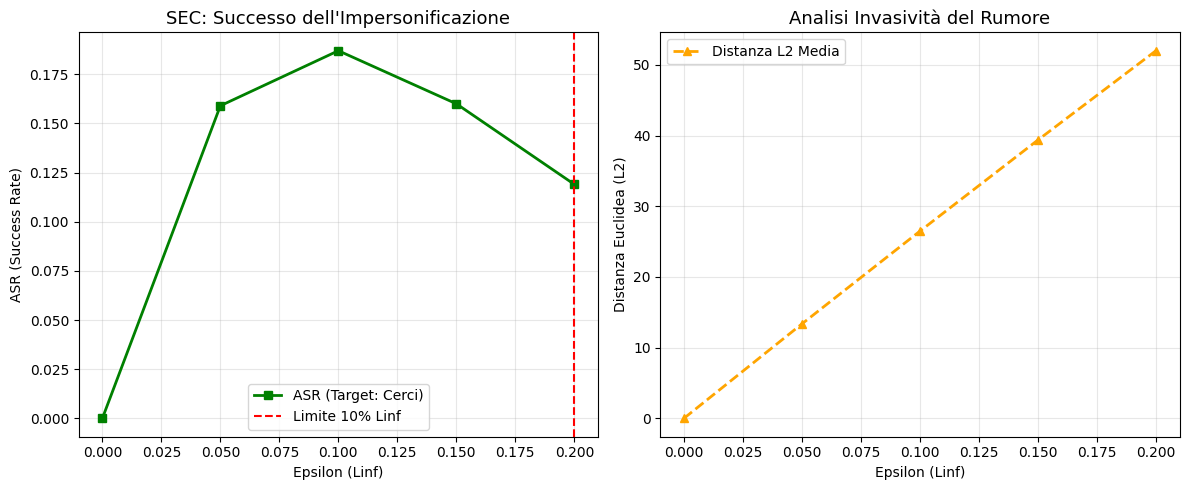

In [ ]:
# Visualizza i risultati dell'attacco targeted.
# Il primo grafico mostra l'Attack Success Rate al variare di epsilon,
# mentre il secondo grafico mostra la distanza L2 media,
# utile per discutere il compromesso tra efficacia e visibilità del rumore.

import matplotlib.pyplot as plt

# Dati estratti dal tuo ultimo run Targeted verso Alessio Cerci
eps_tg = [0.0, 0.05, 0.1, 0.15, 0.2]
asr_tg = [0.0, 0.159, 0.187, 0.160, 0.119]
l2_tg = [0.0, 13.36, 26.48, 39.37, 52.00]

plt.figure(figsize=(12, 5))

# Grafico 1: ASR vs Epsilon (Efficacia dell'impersonificazione)
plt.subplot(1, 2, 1)
plt.plot(eps_tg, asr_tg, marker='s', linestyle='-', color='g', linewidth=2, label='ASR (Target: Cerci)')
plt.axvline(x=0.2, color='r', linestyle='--', label='Limite 10% Linf')
plt.title("SEC: Successo dell'Impersonificazione", fontsize=13)
plt.xlabel("Epsilon (Linf)")
plt.ylabel("ASR (Success Rate)")
plt.grid(True, alpha=0.3)
plt.legend()

# Grafico 2: Invasività (Distanza L2)
plt.subplot(1, 2, 2)
plt.plot(eps_tg, l2_tg, marker='^', linestyle='--', color='orange', linewidth=2, label='Distanza L2 Media')
plt.title("Analisi Invasività del Rumore", fontsize=13)
plt.xlabel("Epsilon (Linf)")
plt.ylabel("Distanza Euclidea (L2)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

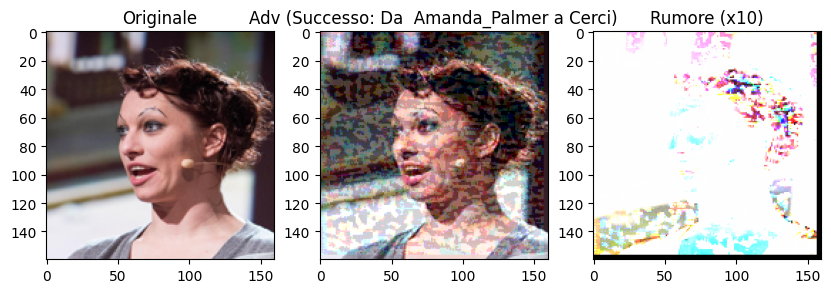

In [ ]:
# Cerchiamo un'immagine dove l'attacco ha avuto successo (predizione = 250)
# Assumendo che tu abbia salvato le predizioni dell'ultimo run a eps 0.1
success_indices = np.where(preds_tg == real_target_idx)[0]

if len(success_indices) > 0:
    idx_successo = success_indices[0] # Prendiamo il primo caso riuscito
    sample_vittima = x_test_all[idx_successo:idx_successo+1]
    # Rigenera o usa il campione adv già creato per la visualizzazione
    show_adv_comparison(sample_vittima, x_adv_tg[idx_successo:idx_successo+1],

                        title=f"Successo: Da {LABELS[y_test_all[idx_successo]]} a Cerci")